# Hands-on 3 — The correlated field model: learning the field *and* its power spectrum

**Course:** NIFTy in a day · **Session:** 14:30 – 15:45

The Wiener filter needs the power spectrum. In practice we don't know it. NIFTy's **correlated field model** puts a
flexible, physically interpretable prior on the spectrum and infers it together with the field.

**You will learn**
1. Build a correlated field with `jft.CorrelatedFieldMaker` and read its latent parameters.
2. Develop intuition for **every** hyper-parameter by looking at prior samples (the most important skill when using NIFTy on real data).
3. Infer a 1-D field + spectrum from gappy data; compare the posterior spectrum with the truth.
4. Use a non-linearity (log-normal field, $s = e^{\phi}$) in 2-D — now the problem is no longer a Wiener filter and needs VI.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np

import nifty.re as jft

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 90

## 1. Anatomy of the model

The correlated field is (schematically)

$$ \phi(x) = \underbrace{\mu}_{\text{offset\_mean}} + \underbrace{\sigma_0\,\xi_0}_{\text{zero mode}} + \frac{1}{V}\,\mathcal H\Big[\, A_\theta(|k|)\; \xi_k \Big](x) $$

where the amplitude spectrum $A_\theta$ is itself generated from standard-normal parameters $\theta$:

$$ \ln A_\theta(k) \;\propto\; \underbrace{\alpha \,\ln k}_{\text{loglogavgslope}} \;+\; \underbrace{\eta\,\mathrm{IWP}_{\text{asperity}}(\ln k)}_{\text{flexibility}}, \qquad \text{normalised so that } \mathrm{std}(\phi - \bar\phi) = \underbrace{a}_{\text{fluctuations}} . $$

* **IWP** = integrated Wiener process: a random, smooth (once-integrated random walk) curve in $\ln k$ that lets the spectrum bend away from a pure power law.
* Each hyper-parameter is given as `(mean, std)`, which becomes a Normal (slope) or LogNormal (positive quantities) prior. The pair (mean, std) is *your* prior knowledge.

In [2]:
def make_cf(n=(256,), prefix="cf", offset_mean=0.0, offset_std=(1e-3, 1e-4),
            fluctuations=(1.0, 0.3), loglogavgslope=(-2.0, 0.5),
            flexibility=(1.0, 0.5), asperity=(0.2, 0.1), kind="amplitude"):
    cfm = jft.CorrelatedFieldMaker(prefix)
    cfm.set_amplitude_total_offset(offset_mean=offset_mean, offset_std=offset_std)
    cfm.add_fluctuations(n, distances=1.0 / n[0], fluctuations=fluctuations,
                         loglogavgslope=loglogavgslope, flexibility=flexibility,
                         asperity=asperity, prefix="ax1", non_parametric_kind=kind)
    return cfm, cfm.finalize()

cfm, cf = make_cf()
print("latent parameters of the correlated field:")
for k, v in cf.domain.items():
    print(f"  {k:22s} shape={v.shape}")

latent parameters of the correlated field:
  cfzeromode             shape=()
  cfax1fluctuations      shape=()
  cfax1loglogavgslope    shape=()
  cfax1spectrum          shape=(127, 2)
  cfax1flexibility       shape=()
  cfax1asperity          shape=()
  cfxi                   shape=(256,)


* `cfxi` — the 256 excitations $\xi_k$ of the field itself.
* `cfzeromode` — the latent of the offset std.
* `cfax1fluctuations`, `cfax1loglogavgslope`, `cfax1flexibility`, `cfax1asperity` — scalar hyper-parameters.
* `cfax1spectrum` — the white noise driving the integrated Wiener process (one value per $|k|$ shell, ×2).

Everything is a standard-normal latent: one inference procedure handles field and spectrum together.

## 2. Building intuition: vary one hyper-parameter at a time

We fix the field excitations $\xi$ and the IWP noise, give each hyper-parameter an almost-zero std (so it's
effectively fixed at its mean) and change one mean at a time. **Do this exercise for every new dataset you model.**

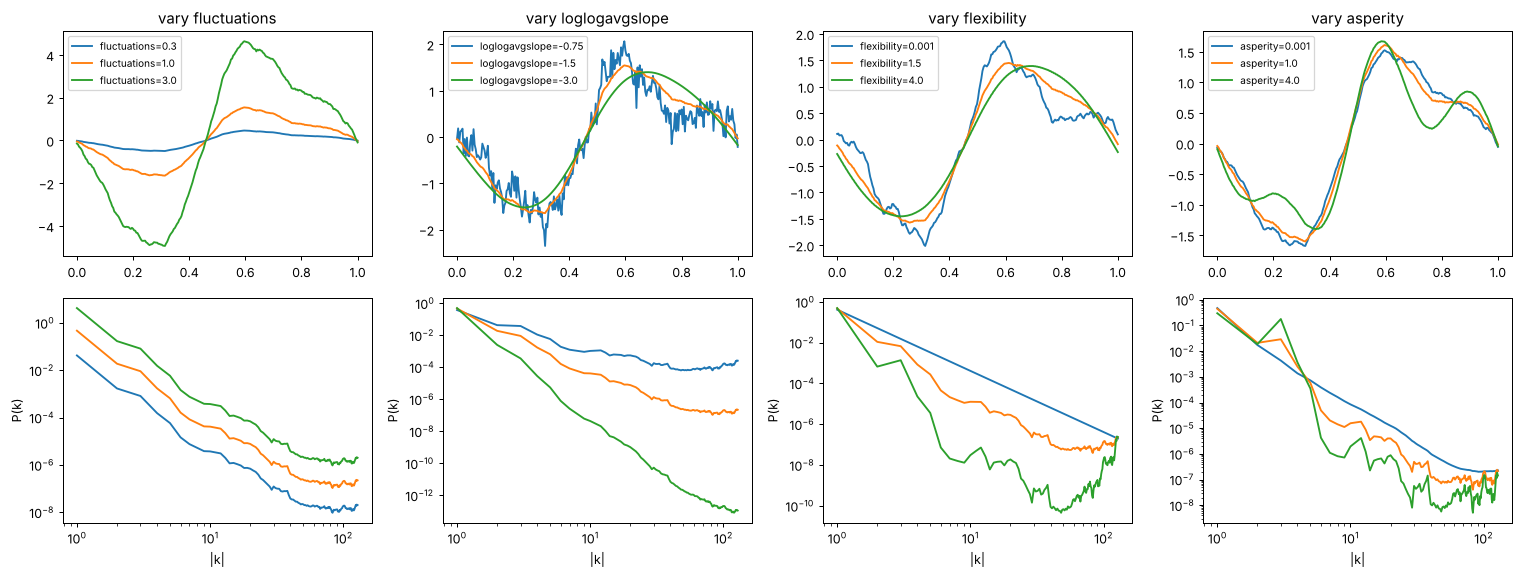

In [3]:
tiny = 1e-8
base = dict(fluctuations=(1.0, tiny), loglogavgslope=(-1.5, tiny), flexibility=(1.0, tiny), asperity=(0.2, tiny))
_, cf_base = make_cf(**base)
xi_fixed = jft.Vector(cf_base.init(random.PRNGKey(3)))     # same random numbers for every panel

sweeps = {
    "fluctuations": [(0.3, tiny), (1.0, tiny), (3.0, tiny)],
    "loglogavgslope": [(-0.75, tiny), (-1.5, tiny), (-3.0, tiny)],
    "flexibility": [(1e-3, tiny), (1.5, tiny), (4.0, tiny)],
    "asperity": [(1e-3, tiny), (1.0, tiny), (4.0, tiny)],
}
fig, axs = plt.subplots(2, 4, figsize=(17, 6.5))
for col, (par, vals) in enumerate(sweeps.items()):
    for v in vals:
        cfm_v, cf_v = make_cf(**{**base, par: v})
        axs[0, col].plot(np.linspace(0, 1, 256), cf_v(xi_fixed), label=f"{par}={v[0]}")
        k = cf_v.target_grids[0].harmonic_grid.mode_lengths[1:]
        axs[1, col].loglog(k, cfm_v.power_spectrum(xi_fixed)[1:])
    axs[0, col].set_title(f"vary {par}"); axs[0, col].legend(fontsize=8)
    axs[1, col].set_xlabel("|k|"); axs[1, col].set_ylabel("P(k)")
plt.tight_layout(); plt.show()

Read the panels like this:
* **fluctuations** scales the field's amplitude — nothing else.
* **loglogavgslope** sets smoothness: −3 is very smooth, −0.75 is rough. (With `non_parametric_kind="amplitude"`, the slope refers to $A(k)$; the power slope is twice that.)
* **flexibility** ≈ 0 → a perfect power law; large → the spectrum may develop bumps and bends.
* **asperity** ≈ 0 → those bends are smooth; large → the spectrum may have sharp peaks (e.g. periodicities in the field).

Now the full prior — all hyper-parameters random — gives the variety a reconstruction can adapt to:

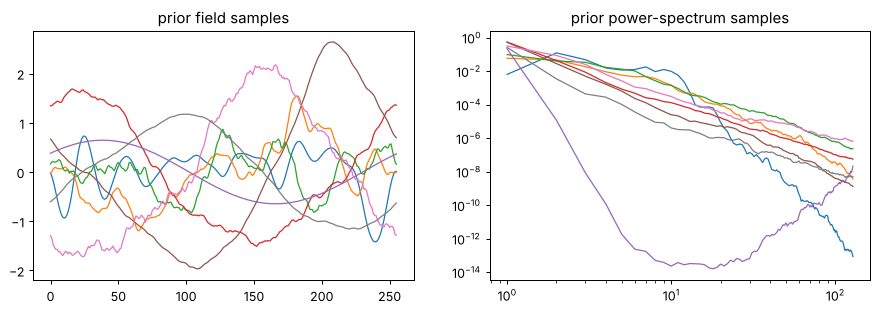

In [4]:
cfm, cf = make_cf()
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
for i in range(8):
    x = cf.init(random.PRNGKey(100 + i))
    axs[0].plot(cf(x), lw=1)
    axs[1].loglog(cf.target_grids[0].harmonic_grid.mode_lengths[1:], cfm.power_spectrum(x)[1:], lw=1)
axs[0].set_title("prior field samples"); axs[1].set_title("prior power-spectrum samples"); plt.show()

## 3. 1-D inference: field + spectrum from gappy, noisy data

In [5]:
N = 256
cfm, cf = make_cf(n=(N,))
x_grid = np.linspace(0, 1, N, endpoint=False)
obs = np.ones(N, bool); obs[60:110] = False; obs[170:185] = False
obs_idx = jnp.array(np.where(obs)[0])


class Observe(jft.Model):
    def __init__(self, field, idx):
        self.field, self.idx = field, idx
        super().__init__(init=field.init)

    def __call__(self, xi):
        return self.field(xi)[self.idx]


sr = Observe(cf, obs_idx)
noise_std = 0.15
key = random.PRNGKey(37)   # seed chosen so the "true" field has some structure
key, k_t, k_n = random.split(key, 3)
xi_true = jft.Vector(sr.init(k_t))
field_true = cf(xi_true)
d = sr(xi_true) + noise_std * random.normal(k_n, sr.target.shape)

lh = jft.Gaussian(d, noise_cov_inv=lambda r: r / noise_std**2).amend(sr)

delta = 1e-4
key, k_i, k_o = random.split(key, 3)
samples, state = jft.optimize_kl(
    lh,
    jft.Vector(lh.init(k_i)) * 0.1,               # start near the prior mean: small initial latents
    n_total_iterations=6,
    n_samples=lambda i: 4 if i < 2 else 10,      # few samples early, more later
    key=k_o,
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10, maxiter=200)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)),
    sample_mode="nonlinear_resample",
)
print("VI iterations done:", int(state.nit), "| number of posterior samples:", len(samples))

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


...

N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0006 E:+3.7054e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5)
OPTIMIZE_KL: #(KL minimization steps) 12
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.96±     0.1, avg:   +0.015±   0.061, #dof:    191'

OPTIMIZE_KL: Prior residual(s):
cfax1asperity           :: 'reduced Chi²:     1.3±     1.8, avg:    -0.29±     1.1, #dof:      1'
cfax1flexibility        :: 'reduced Chi²:    0.57±    0.58, avg:    -0.29±     0.7, #dof:      1'
cfax1fluctuations       :: 'reduced Chi²:     1.6±     1.4, avg:     -1.1±    0.66, #dof:      1'
cfax1loglogavgslope     :: 'reduced Chi²:     2.3±     1.3, avg:     +1.4±    0.46, #dof:      1'
cfax1spectrum           :: 'reduced Chi²:     1.0±   0.095, avg:   -0.069±    0.06, #dof:    254'
cfxi                    :: 'reduced Chi²:     1.1±    0.13, avg:   +0.044±   0.039, #dof:    256'
cfzeromode              :: 'reduced Chi²:    0.74±    0.58, avg:  -0.0018±    0.86, #d

VI iterations done: 6 | number of posterior samples: 20


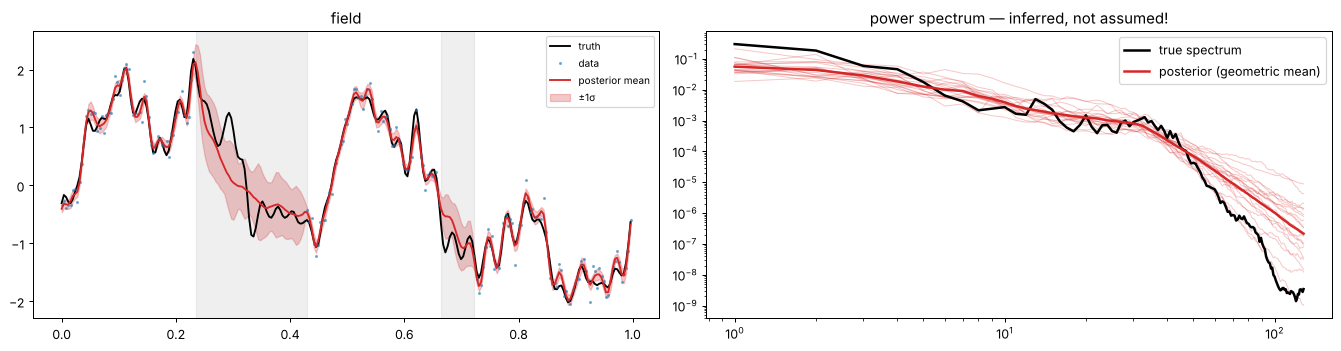

In [6]:
fld = jnp.stack([cf(s) for s in samples])
ps = jnp.stack([cfm.power_spectrum(s)[1:] for s in samples])
kk = cf.target_grids[0].harmonic_grid.mode_lengths[1:]

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
ax = axs[0]
ax.plot(x_grid, field_true, "k", label="truth")
ax.plot(x_grid[obs], d, ".", ms=3, alpha=0.5, label="data")
ax.plot(x_grid, fld.mean(0), "C3", label="posterior mean")
ax.fill_between(x_grid, fld.mean(0) - fld.std(0), fld.mean(0) + fld.std(0), color="C3", alpha=0.25, label="±1σ")
for a, b in [(60, 110), (170, 185)]:
    ax.axvspan(a / N, b / N, color="grey", alpha=0.12)
ax.legend(fontsize=8); ax.set_title("field")
ax = axs[1]
for p in ps:
    ax.loglog(kk, p, "C3", alpha=0.25, lw=0.8)
ax.loglog(kk, cfm.power_spectrum(xi_true)[1:], "k", lw=2, label="true spectrum")
ax.loglog(kk, jnp.exp(jnp.log(ps).mean(0)), "C3", lw=2, label="posterior (geometric mean)")
ax.legend(); ax.set_title("power spectrum — inferred, not assumed!"); plt.tight_layout(); plt.show()

The spectrum is well constrained at small and intermediate $k$ (lots of data) and fans out at high $k$ where
the noise dominates — exactly the honest behaviour you want.

**Hyper-parameter posteriors.** Every hyper-parameter is accessible: apply the sub-model to the samples.

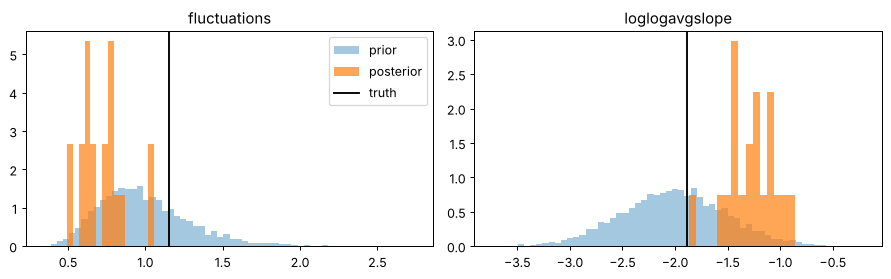

In [7]:
# The hyper-parameter latents are standard normal; map them to physical values with the *same* prior transforms
# the maker used: LogNormal for `fluctuations`, Normal for `loglogavgslope`.
to_fluct = jft.LogNormalPrior(1.0, 0.3, name="cfax1fluctuations")
to_slope = jft.NormalPrior(-2.0, 0.5, name="cfax1loglogavgslope")
post_fl = np.array([to_fluct(s) for s in samples]); post_sl = np.array([to_slope(s) for s in samples])
prior_xi = random.normal(random.PRNGKey(0), (4000,))
fig, axs = plt.subplots(1, 2, figsize=(10, 3.2))
axs[0].hist(np.array(jax.vmap(lambda z: to_fluct({"cfax1fluctuations": z}))(prior_xi)), 60, density=True, alpha=0.4, label="prior")
axs[0].hist(post_fl, 15, density=True, alpha=0.7, label="posterior"); axs[0].axvline(float(to_fluct(xi_true)), c="k", label="truth")
axs[1].hist(np.array(jax.vmap(lambda z: to_slope({"cfax1loglogavgslope": z}))(prior_xi)), 60, density=True, alpha=0.4, label="prior")
axs[1].hist(post_sl, 15, density=True, alpha=0.7, label="posterior"); axs[1].axvline(float(to_slope(xi_true)), c="k", label="truth")
axs[0].set_title("fluctuations"); axs[1].set_title("loglogavgslope"); axs[0].legend(); plt.tight_layout(); plt.show()

**Don't over-read single hyper-parameters.** They are partly *degenerate*: a shallower slope plus a downward bend
from `flexibility` can produce the same spectrum as a steeper straight line; fluctuations trade off against the
zero mode. At high $k$ the data are noise-dominated, so the spectrum there is prior-driven. Judge the **spectrum
and the field**, which are well constrained, not each knob in isolation.

## 4. 2-D, non-linear: a log-normal field

Many physical quantities are positive (densities, fluxes) and vary over orders of magnitude. Model them as
$s = e^{\phi}$ with $\phi$ a correlated field. The model is **non-linear** → posterior non-Gaussian → we need VI.
We add a `scaling` LogNormal prior, combine `init`s, and write a custom `jft.Model`.

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0001 E:+4.3793e+04
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 2, 3, 2)
OPTIMIZE_KL: #(KL minimization steps) 20
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     8.4±    0.31, avg:   -0.069±    0.25, #dof:   9216'

OPTIMIZE_KL: Prior residual(s):
cfaxasperity            :: 'reduced Chi²: 4.5e+01±   2e+01, avg:     +6.5±     1.6, #dof:      1'
cfaxflexibility         :: 'reduced Chi²:     6.7±     5.1, avg:     -2.3±     1.1, #dof:      1'
cfaxfluctuations        :: 'reduced Chi²:     3.4±     3.2, avg:     +1.5±     1.1, #dof:      1'
cfaxloglogavgslope      :: 'reduced Chi²: 1.4e+01±     4.7, avg:     -3.7±    0.64, #dof:      1'
cfaxspectrum            :: 'reduced Chi²:     1.0±   0.017, avg:  -0.0011±  0.0039, #dof:   1910'
cfxi                    :: 'reduced Chi²:    0.85±  0.0086, avg:  +0.0013±  0.0093, #dof:   9216'
cfzeromode              :: 'reduced Chi²:    0.15±    0.15, avg:    +0.11±    0.37, #dof:      1'
scale                   :: 'reduced 

OPTIMIZE_KL: Starting 0002


...

N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0006 E:+1.8581e+04
OPTIMIZE_KL: #(Nonlinear sampling steps) (5, 5, 5, 5, 5, 5, 5, 5, 3, 5)
OPTIMIZE_KL: #(KL minimization steps) 6
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     2.7±   0.028, avg:   +0.011±   0.012, #dof:   9216'

OPTIMIZE_KL: Prior residual(s):
cfaxasperity            :: 'reduced Chi²: 4.2e+01± 1.3e+01, avg:     +6.4±     1.0, #dof:      1'
cfaxflexibility         :: 'reduced Chi²:     5.8±     2.9, avg:     -2.3±    0.62, #dof:      1'
cfaxfluctuations        :: 'reduced Chi²:     2.9±     1.4, avg:     +1.7±    0.42, #dof:      1'
cfaxloglogavgslope      :: 'reduced Chi²:   2e+01±     2.0, avg:     -4.4±    0.22, #dof:      1'
cfaxspectrum            :: 'reduced Chi²:     1.0±   0.059, avg:    -0.03±   0.022, #dof:   1910'
cfxi                    :: 'reduced Chi²:     1.1±   0.015, avg:  +0.0047±   0.013, #dof:   9216'
cfzeromode              :: 'reduced Chi²:     1.1±    0.97, avg:   +0.087±     1.1, #dof:      1'
scale              

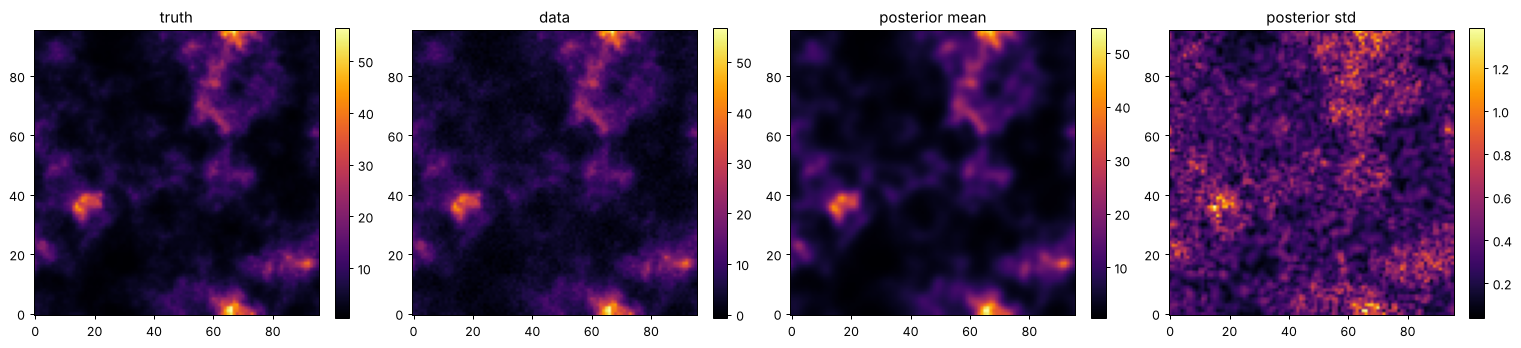

In [8]:
dims = (96, 96)
cfm2 = jft.CorrelatedFieldMaker("cf")
cfm2.set_amplitude_total_offset(offset_mean=0.0, offset_std=(1e-3, 1e-4))
cfm2.add_fluctuations(dims, distances=1.0 / dims[0], fluctuations=(1.0, 0.5),
                      loglogavgslope=(-3.0, 0.5), flexibility=(1.0, 0.5), asperity=(0.3, 0.2),
                      prefix="ax", non_parametric_kind="power")
phi = cfm2.finalize()


class LogNormalSky(jft.Model):
    def __init__(self, phi):
        self.phi = phi
        self.scale = jft.LogNormalPrior(2.0, 1.0, name="scale")
        super().__init__(init=self.phi.init | self.scale.init)

    def __call__(self, xi):
        return self.scale(xi) * jnp.exp(self.phi(xi))


sky = LogNormalSky(phi)
key, k_t, k_n = random.split(key, 3)
xi_true2 = jft.Vector(sky.init(k_t))
sky_true = sky(xi_true2)
noise2 = 0.1 * float(sky_true.mean())
data2 = sky_true + noise2 * random.normal(k_n, dims)

lh2 = jft.Gaussian(data2, noise_cov_inv=lambda r: r / noise2**2).amend(sky)
key, k_i, k_o = random.split(key, 3)
samples2, state2 = jft.optimize_kl(
    lh2, jft.Vector(lh2.init(k_i)) * 0.1, n_total_iterations=6, n_samples=lambda i: 2 if i < 2 else 5, key=k_o,
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta * jft.size(lh2.domain) / 10, maxiter=100)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)),
)
m2, s2 = jft.mean_and_std(tuple(sky(s) for s in samples2))
fig, axs = plt.subplots(1, 4, figsize=(17, 4))
for ax, (t, im) in zip(axs, [("truth", sky_true), ("data", data2), ("posterior mean", m2), ("posterior std", s2)]):
    h = ax.imshow(im.T, origin="lower", cmap="inferno"); ax.set_title(t); plt.colorbar(h, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Practical checklist for correlated fields
1. **Prior predictive check first.** Draw 10+ prior samples; real data should look like a *plausible* draw. If not, fix (mean, std) of the hyper-parameters.
2. **Zero padding** for non-periodic data: the FFT assumes periodic boundaries. Make the field domain ~1.5–2× larger than the observed region and only observe the inner part, otherwise structure "wraps around".
3. `offset_std` controls the zero mode; if your data have an unknown overall level, give it a realistic std.
4. Use `non_parametric_kind="power"` if you think in $P(k)$, `"amplitude"` (default) for $A(k)$ — the slope means differ by a factor 2.
5. Multi-axis fields (e.g. space × frequency, space × time): call `add_fluctuations` once **per sub-domain**; the joint spectrum is the product. **Gotcha:** then each `fluctuations` is relative to `offset_std`, so give the offset an O(1) std (see E3.3). For a field whose spectrum varies from pixel to pixel, use one multi-dimensional `add_fluctuations` call instead (see `demos/re/a_spatio-spectral_plotting.py`). Use `jft.CorrelatedFieldMaker.add_fluctuations_matern` for a parametric Matérn-type spectrum.

## ✏️ Exercises
**E3.1** Re-run §3 with a much smaller prior on `flexibility` (`(1e-3, 1e-4)`). What does the posterior spectrum look like now, and is the field reconstruction worse?

**E3.2** Implement zero-padding in §3: field on 512 pixels, data only from pixels 128–384. Compare the edges with and without padding.

**E3.3** Build a **space × time** field: `add_fluctuations((64,), ..., prefix="space")` then `add_fluctuations((40,), ..., prefix="time")`.
Plot a prior sample as an image (space vs time). Give time a much steeper slope — what happens?

**E3.4** Replace the Gaussian likelihood in §4 by `jft.Poissonian` on integer counts (see Hands-on 5 for the solution).

In [9]:
# Your work here

---
## Solutions

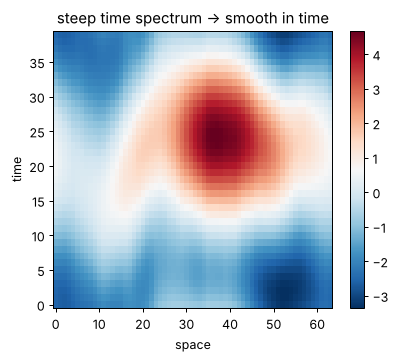

In [10]:
# E3.3 — space × time correlated field
cfm_st = jft.CorrelatedFieldMaker("st")
# GOTCHA: with several axes, each `fluctuations` is measured RELATIVE to the zero-mode std (offset_std).
# With offset_std=1e-3 the field std would explode to ~1000. Use an O(1) offset_std for product fields.
cfm_st.set_amplitude_total_offset(offset_mean=0.0, offset_std=(1.0, 1e-3))
cfm_st.add_fluctuations((64,), distances=1 / 64, fluctuations=(1.0, 0.1), loglogavgslope=(-2.0, 0.1),
                        flexibility=None, asperity=None, prefix="space")
cfm_st.add_fluctuations((40,), distances=1 / 40, fluctuations=(1.0, 0.1), loglogavgslope=(-5.0, 0.1),
                        flexibility=None, asperity=None, prefix="time")
st = cfm_st.finalize()
plt.figure(figsize=(5, 4)); plt.imshow(st(st.init(random.PRNGKey(0))).T, aspect="auto", origin="lower", cmap="RdBu_r")
plt.xlabel("space"); plt.ylabel("time"); plt.title("steep time spectrum → smooth in time"); plt.colorbar(); plt.show()

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


...

N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0005 E:+6.2184e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 5, 5)
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.95±   0.061, avg:  +0.0098±   0.067, #dof:    206'

OPTIMIZE_KL: Prior residual(s):
padax1asperity          :: 'reduced Chi²:     1.5±     1.6, avg:     +0.9±    0.84, #dof:      1'
padax1flexibility       :: 'reduced Chi²:   1e+01±     8.3, avg:     -2.9±     1.3, #dof:      1'
padax1fluctuations      :: 'reduced Chi²:     1.8±     1.7, avg:     +1.1±    0.79, #dof:      1'
padax1loglogavgslope    :: 'reduced Chi²:     2.1±    0.43, avg:     +1.4±    0.15, #dof:      1'
padax1spectrum          :: 'reduced Chi²:    0.97±   0.072, avg:  +0.0025±   0.024, #dof:    510'
padxi                   :: 'reduced Chi²:     1.0±   0.055, avg:  +0.0037±   0.039, #dof:    512'
padzeromode             :: 'reduced Chi²:     1.4±     1.1, avg:  +0.0049±     1.2, #dof:      1'




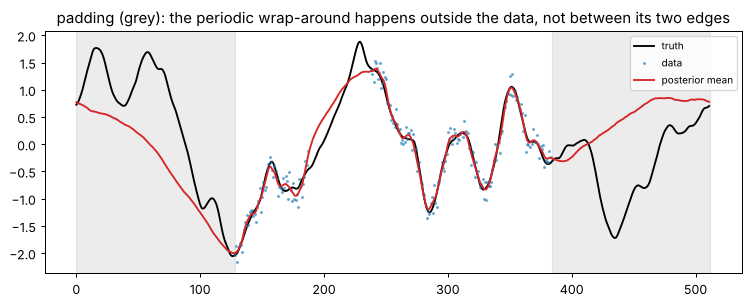

In [11]:
# E3.2 — zero padding
N_pad = 512
cfm_p, cf_p = make_cf(n=(N_pad,), prefix="pad")
inner = jnp.arange(128, 384)
obs_p = inner[np.r_[0:60, 110:256]]          # same gap pattern, inside the padded domain
sr_p = Observe(cf_p, obs_p)
xi_tp = jft.Vector(sr_p.init(random.PRNGKey(5)))
d_p = sr_p(xi_tp) + noise_std * random.normal(random.PRNGKey(6), sr_p.target.shape)
lh_p = jft.Gaussian(d_p, noise_cov_inv=lambda r: r / noise_std**2).amend(sr_p)
smp_p, _ = jft.optimize_kl(lh_p, jft.Vector(lh_p.init(random.PRNGKey(7))) * 0.1, n_total_iterations=5, n_samples=6,
                           key=random.PRNGKey(8),
                           draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(maxiter=200)),
                           nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
                           kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)))
fp = jnp.stack([cf_p(s) for s in smp_p])
plt.figure(figsize=(10, 3.5)); plt.plot(cf_p(xi_tp), "k", label="truth")
plt.plot(np.array(obs_p), d_p, ".", ms=3, alpha=0.5, label="data")
plt.plot(fp.mean(0), "C3", label="posterior mean"); plt.axvspan(0, 128, color="grey", alpha=0.15); plt.axvspan(384, 512, color="grey", alpha=0.15)
plt.legend(fontsize=8); plt.title("padding (grey): the periodic wrap-around happens outside the data, not between its two edges"); plt.show()